<a href="https://colab.research.google.com/github/selenakdik/bitki-sagligi-teshisi/blob/main/Bitki_Hastalik_Teshisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q "/content/drive/MyDrive/bitki_veriseti.zip" -d "/content/dataset"

In [ ]:
import os
icerik = os.listdir('/content/dataset')
print("Veri setindeki ana klasörler:", icerik)

Veri setindeki ana klasörler: ['plantvillage dataset']


In [ ]:
import os
alt_klasorler = os.listdir('/content/dataset/plantvillage dataset')
print("Alt klasörler:", alt_klasorler)

Alt klasörler: ['grayscale', 'color', 'segmented']


In [ ]:
import os
color_path = '/content/dataset/plantvillage dataset/color'

# Klasörleri (sınıfları) listele ve alfabetik sırala
classes = sorted(os.listdir(color_path))

print(f"Toplam Sınıf Sayısı: {len(classes)}\n")
print(f"{'Hastalık Adı':<50} | {'Fotoğraf Sayısı'}")
print("-" * 70)

total_images = 0
for cls in classes:
    # Her bir hastalık klasörünün yolunu oluştur
    class_path = os.path.join(color_path, cls)
    # İçindeki dosya sayısını say
    num_images = len(os.listdir(class_path))
    total_images += num_images
    print(f"{cls:<50} | {num_images}")

print("-" * 70)
print(f"Toplam Renkli Fotoğraf Sayısı: {total_images}")

Toplam Sınıf Sayısı: 38

Hastalık Adı                                       | Fotoğraf Sayısı
----------------------------------------------------------------------
Apple___Apple_scab                                 | 630
Apple___Black_rot                                  | 621
Apple___Cedar_apple_rust                           | 275
Apple___healthy                                    | 1645
Blueberry___healthy                                | 1502
Cherry_(including_sour)___Powdery_mildew           | 1052
Cherry_(including_sour)___healthy                  | 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | 513
Corn_(maize)___Common_rust_                        | 1192
Corn_(maize)___Northern_Leaf_Blight                | 985
Corn_(maize)___healthy                             | 1162
Grape___Black_rot                                  | 1180
Grape___Esca_(Black_Measles)                       | 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         | 1076
Grape___healthy              

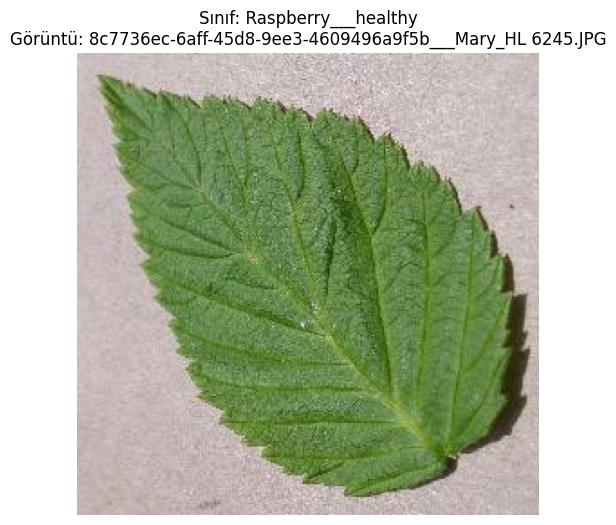

Görselin boyutu: (256, 256, 3)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Rastgele bir sınıf seçme
random_class = random.choice(classes)
class_path = os.path.join(color_path, random_class)

# O sınıftan rastgele bir fotoğraf seçme
random_image = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, random_image)

img = mpimg.imread(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Sınıf: {random_class}\nGörüntü: {random_image}")
plt.axis('off')
plt.show()

print(f"Görselin boyutu: {img.shape}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Veri artırma katmanlarını tanımlıyoruz
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"), # Hem yatay hem dikey çevir
  layers.RandomRotation(0.2), # %20 oranında rastgele döndür
  layers.RandomZoom(0.1),    # %10 oranında rastgele yakınlaştır
  layers.RandomContrast(0.1) # Parlaklığı biraz değiştir
])

In [ ]:
# Görüntü boyutlarını ve paket miktarını belirleme
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
color_path = '/content/dataset/plantvillage dataset/color'

# Eğitim verileri (%80)
train_ds = tf.keras.utils.image_dataset_from_directory(
    color_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama verileri (%20)
val_ds = tf.keras.utils.image_dataset_from_directory(
    color_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
import numpy as np
import os

# Sınıf isimlerini veri yükleyicimizden al
class_names = train_ds.class_names

# Her sınıfın ağırlığını hesaplama
class_weights = {}
total_images = 54305
n_classes = 38

for i, name in enumerate(class_names):
    # O sınıfın klasöründeki dosya sayısını bul
    class_count = len(os.listdir(os.path.join(color_path, name)))

    # Formül: Toplam / (Sınıf Sayısı * Sınıftaki Veri Sayısı)
    # Bu sayede az verisi olan sınıfın ağırlığı yüksek çıkar.
    weight = total_images / (n_classes * class_count)
    class_weights[i] = weight

print("Sınıf ağırlıkları başarıyla hesaplandı!")
# Örnek olarak ilk 3 sınıfın ağırlığına bakarsak:
for i in range(3):
    print(f"{class_names[i]}: {class_weights[i]:.2f}")

Sınıf ağırlıkları başarıyla hesaplandı!
Apple___Apple_scab: 2.27
Apple___Black_rot: 2.30
Apple___Cedar_apple_rust: 5.20


In [ ]:
import tensorflow as tf

# HİPERPARAMETRE: Öğrenme hızı ayarı
ogrenme_hizi = 0.001
optimizasyon_araci = tf.keras.optimizers.Adam(learning_rate=ogrenme_hizi)

# EARLYSTOPPING
erken_durdurma = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("EarlyStopping ve Hiperparametre başarıyla tanımlandı!")

EarlyStopping ve Hiperparametre başarıyla tanımlandı!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ÖNCE: Eksik olan veri artırma katmanını burada tanımlayalım
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

# SONRA: Modeli kuralım
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'), # Nöron sayısı

    # OVERFITTING önlemi
    layers.Dropout(0.5),

    layers.Dense(38, activation='softmax')
])

# Modeli derleme
model.compile(
    optimizer=optimizasyon_araci,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Güncel model mimarisi oluşturuldu ve derlendi!")

Güncel model mimarisi oluşturuldu ve derlendi!


In [ ]:
# Eğitimi başlatma
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[erken_durdurma],
    class_weight=class_weights
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 110s 79ms/step - accuracy: 0.1585 - loss: 3.0007 - val_accuracy: 0.3219 - val_loss: 2.3759
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.4625 - loss: 1.7755 - val_accuracy: 0.5566 - val_loss: 1.4524
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 78ms/step - accuracy: 0.6108 - loss: 1.2924 - val_accuracy: 0.6995 - val_loss: 0.9934
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 77ms/step - accuracy: 0.6725 - loss: 1.0622 - val_accuracy: 0.7273 - val_loss: 0.8890
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - accuracy: 0.7146 - loss: 0.9272 - val_accuracy: 0.7347 - val_loss: 0.8312
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.7425 - loss: 0.8102 - val_accuracy: 0.8220 - val_loss: 0.5463
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.7681 - loss: 0.7414 - val_accuracy: 0.8310 - val_loss: 0.5309
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 102s 75ms/step - accuracy: 

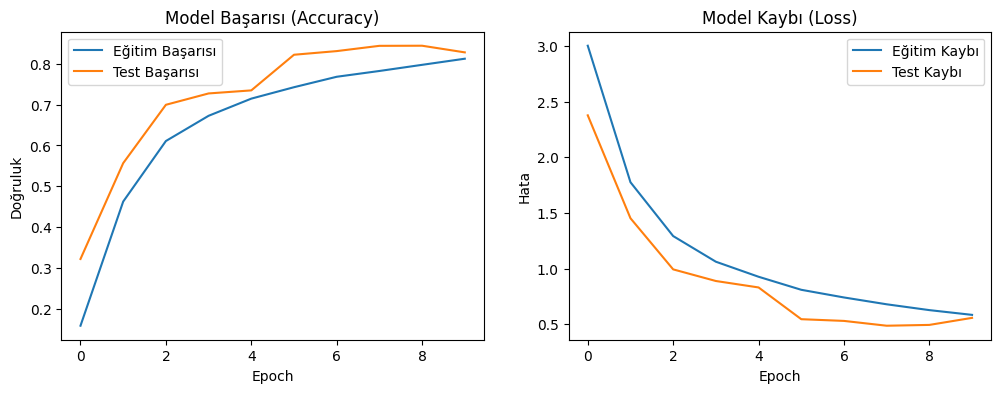

In [ ]:
import matplotlib.pyplot as plt

# Doğruluk (Accuracy) Grafiği
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Test Başarısı')
plt.title('Model Başarısı (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Test Kaybı')
plt.title('Model Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Hata')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


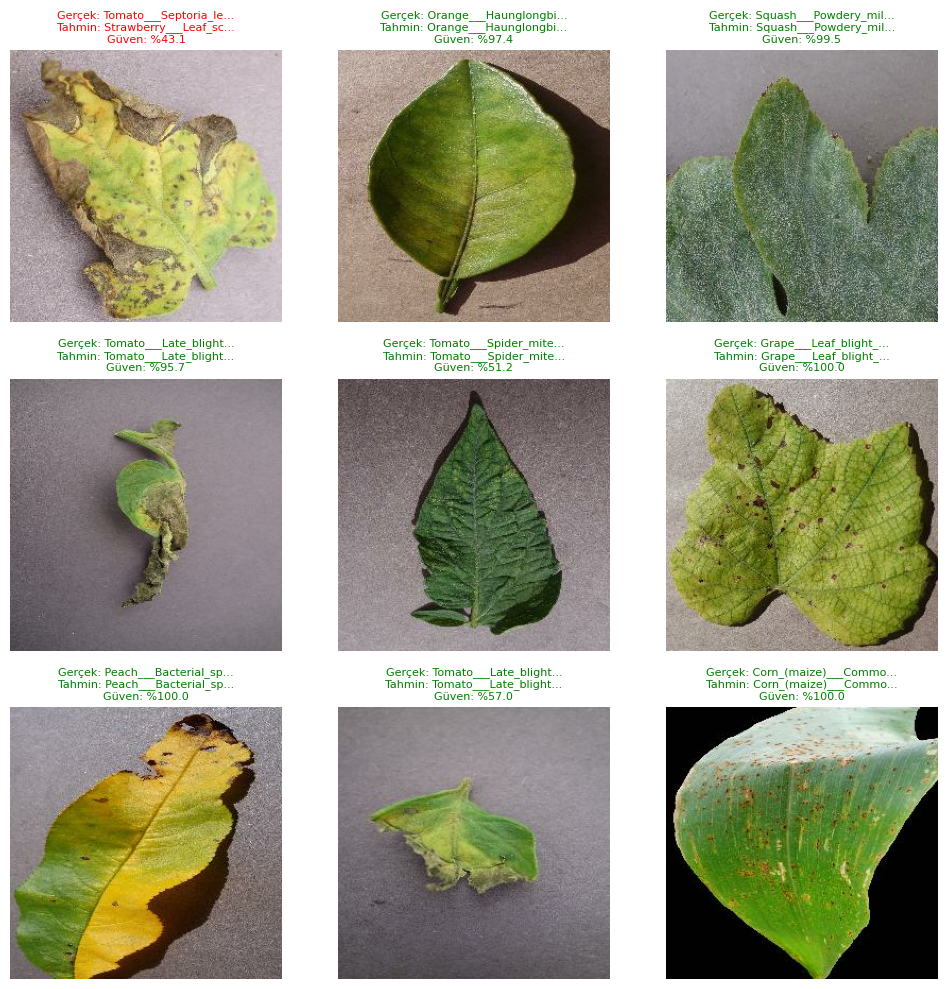

In [ ]:
import numpy as np
import random

# Doğrulama setinden bir paket (batch) resim alıyoruz
image_batch, label_batch = next(iter(val_ds))

# Modelin tahminlerini alalım
predictions = model.predict(image_batch)

# Rastgele 9 tane benzersiz indeks seçiyoruz (0 ile 31 arası) (batch size 32)
random_indices = random.sample(range(len(image_batch)), 9)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(random_indices):
    ax = plt.subplot(3, 3, i + 1)

    # Seçilen rastgele indeksteki resmi göster
    plt.imshow(image_batch[idx].numpy().astype("uint8"))

    actual_label = class_names[label_batch[idx]]
    predicted_label = class_names[np.argmax(predictions[idx])]
    confidence = 100 * np.max(predictions[idx])

    color = "green" if actual_label == predicted_label else "red"


    plt.title(f"Gerçek: {actual_label[:20]}...\nTahmin: {predicted_label[:20]}...\nGüven: %{confidence:.1f}",
              color=color, fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Modeli .h5 formatında kaydetme
model.save('bitki_hastalik_modeli_v1.h5')
print("Model başarıyla kaydedildi!")

Model başarıyla kaydedildi!


In [ ]:
import shutil

# Modeli Colab hafızasından Drive'ına kopyalar
shutil.copy('bitki_hastalik_modeli_v1.h5', '/content/drive/MyDrive/bitki_hastalik_modeli_v1.h5')

print("Model başarıyla Google Drive'a kopyalandı!")

Model başarıyla Google Drive'a kopyalandı!
